### Standard GNN Model with feature engineered data - KFold and Optuna hyperparameter tuning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import NearestNeighbors

import tensorflow as tf
from tensorflow.keras import layers, Model

import lime.lime_tabular
import shap
from IPython.display import display, HTML

/Users/amalshar/miniforge3/envs/mlenv64/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = "/Users/amalshar/Desktop/USD/Fall 2025/Data Analysis/Final Project/daily_2025_engineered_data.csv"
TARGET = "DailyAQI"

# Base + Engineered Features (same set you used elsewhere)
BASE_FEATURES = [
    "CO", "SO2", "NO2", "O3", "PM25",
    "BarometricPressure", "Temperature", "WindResultant"
]

ENG_FEATURES = [
    "AQI_lag_1","AQI_lag_3","AQI_lag_7",
    "AQI_roll_3","AQI_roll_7",
    "CO_roll_3","CO_roll_7","NO2_roll_3","NO2_roll_7",
    "PM25_roll_3","PM25_roll_7","O3_roll_3","O3_roll_7",
    "month","dayofweek","is_weekend","dayofyear",
    "PM25xTemp","NO2xWind"
]

FEATURES = BASE_FEATURES + ENG_FEATURES

K_NEIGHBORS = 8  # k for k-NN graph

# %%
df = pd.read_csv(DATA_PATH)
df["Date Local"] = pd.to_datetime(df["Date Local"], errors="coerce")

# Keep only complete rows
df = df.dropna(subset=FEATURES + [TARGET]).copy()
df = df.sort_values("Date Local").reset_index(drop=True)

print("Rows after cleaning:", len(df))
print("Date range:", df["Date Local"].min(), "->", df["Date Local"].max())

# %%
X_np = df[FEATURES].values.astype(np.float32)
y_np = df[TARGET].values.astype(np.float32)

# Standardize features
scaler_X = StandardScaler().fit(X_np)
X_scaled = scaler_X.transform(X_np).astype(np.float32)

n_nodes, n_features = X_scaled.shape
print("Nodes:", n_nodes, "| Features:", n_features)

Rows after cleaning: 91740
Date range: 2025-01-01 00:00:00 -> 2025-07-01 00:00:00
Nodes: 91740 | Features: 27


In [3]:
dates_sorted = df["Date Local"].values
cut1 = np.quantile(dates_sorted, 0.70)
cut2 = np.quantile(dates_sorted, 0.80)

train_mask = df["Date Local"] <= cut1
val_mask   = (df["Date Local"] > cut1) & (df["Date Local"] <= cut2)
test_mask  = df["Date Local"] > cut2

train_idx = np.where(train_mask)[0]
val_idx   = np.where(val_mask)[0]
test_idx  = np.where(test_mask)[0]

print(f"Train/Val/Test sizes: {len(train_idx)}, {len(val_idx)}, {len(test_idx)}")

# Convert y to 2D for TF
y_np_2d = y_np.reshape(-1, 1)



Train/Val/Test sizes: 64291, 9124, 18325


In [4]:
nn_model = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, algorithm="ball_tree")
nn_model.fit(X_scaled)
distances, indices = nn_model.kneighbors(X_scaled)

edge_list = []

for i in range(n_nodes):
    for j in indices[i][1:]:  # skip self index
        edge_list.append([i, j])  # edge j -> i
        edge_list.append([j, i])  # make it undirected

# Add self loops
for i in range(n_nodes):
    edge_list.append([i, i])

edge_index_np = np.array(edge_list, dtype=np.int32)  # shape (E, 2)
print("edge_index shape:", edge_index_np.shape)


edge_index shape: (1559580, 2)


In [5]:
class GraphConv(layers.Layer):
    """
    Simple mean-aggregation graph convolution:
      h_i = mean_{j in N(i)} (x_j W)
    where neighbors come from edge_index (E, 2) with (dst, src).
    """
    def __init__(self, units, edge_index, num_nodes, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.num_nodes = num_nodes
        self.edge_index = tf.constant(edge_index, dtype=tf.int32)  # (E, 2)
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        in_dim = int(input_shape[-1])
        self.kernel = self.add_weight(
            shape=(in_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="kernel"
        )

    def call(self, x):
        # x: (N, F)
        xw = tf.matmul(x, self.kernel)  # (N, units)
        dst = self.edge_index[:, 0]     # destination nodes
        src = self.edge_index[:, 1]     # source nodes

        src_feat = tf.gather(xw, src)   # (E, units)

        # sum over neighbors
        neigh_sum = tf.math.unsorted_segment_sum(
            src_feat, dst, num_segments=self.num_nodes
        )

        # count of neighbors per node
        ones = tf.ones((tf.shape(src)[0], 1), dtype=tf.float32)
        neigh_count = tf.math.unsorted_segment_sum(
            ones, dst, num_segments=self.num_nodes
        )
        neigh_count = tf.maximum(neigh_count, 1.0)

        out = neigh_sum / neigh_count  # mean aggregation

        if self.activation is not None:
            out = self.activation(out)
        return out


In [6]:
tf.keras.backend.clear_session()

edge_index_tf = edge_index_np  # we'll pass to layer
num_nodes = n_nodes

inputs = layers.Input(shape=(n_features,))  # (N, F), but we treat the whole graph at once

gcn1 = GraphConv(64, edge_index=edge_index_tf, num_nodes=num_nodes, activation="relu")(inputs)
gcn2 = GraphConv(32, edge_index=edge_index_tf, num_nodes=num_nodes, activation="relu")(gcn1)
outputs = layers.Dense(1)(gcn2)  # regression

gnn_model = Model(inputs=inputs, outputs=outputs)
gnn_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

gnn_model.summary()

# %%
# Build boolean masks as tf constants
train_mask_tf = tf.constant(train_mask)
val_mask_tf   = tf.constant(val_mask)
test_mask_tf  = tf.constant(test_mask)

X_tf = tf.constant(X_scaled, dtype=tf.float32)
y_tf = tf.constant(y_np_2d, dtype=tf.float32)

# Custom training loop to apply masks
EPOCHS = 80
best_val_mse = np.inf
best_weights = None

for epoch in range(1, EPOCHS + 1):
    with tf.GradientTape() as tape:
        preds = gnn_model(X_tf, training=True)  # (N,1)
        preds_train = tf.boolean_mask(preds, train_mask_tf)
        y_train_true = tf.boolean_mask(y_tf, train_mask_tf)
        loss = tf.reduce_mean(tf.keras.losses.mse(y_train_true, preds_train))

    grads = tape.gradient(loss, gnn_model.trainable_variables)
    gnn_model.optimizer.apply_gradients(zip(grads, gnn_model.trainable_variables))

    # Validation
    preds_val = gnn_model(X_tf, training=False)
    preds_val_masked = tf.boolean_mask(preds_val, val_mask_tf)
    y_val_true = tf.boolean_mask(y_tf, val_mask_tf)
    val_mse = tf.reduce_mean(tf.keras.losses.mse(y_val_true, preds_val_masked)).numpy()

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_weights = gnn_model.get_weights()

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train loss={loss.numpy():.3f} | Val MSE={val_mse:.3f}")

# Load best weights
if best_weights is not None:
    gnn_model.set_weights(best_weights)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 27)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv (GraphConv)          │ (91740, 64)            │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_1 (GraphConv)        │ (91740, 32)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (91740, 1)             │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,809 (14.88 KB)

 Trainable params: 3,809 (14.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 001 | Train loss=4006.244 | Val MSE=2435.016
Epoch 010 | Train loss=3868.716 | Val MSE=2363.522
Epoch 020 | Train loss=3717.320 | Val MSE=2281.801
Epoch 030 | Train loss=3539.562 | Val MSE=2191.734
Epoch 040 | Train loss=3302.565 | Val MSE=2087.056
Epoch 050 | Train loss=2995.830 | Val MSE=1963.691
Epoch 060 | Train loss=2620.468 | Val MSE=1819.203
Epoch 070 | Train loss=2195.510 | Val MSE=1654.586
Epoch 080 | Train loss=1767.868 | Val MSE=1476.036



GNN Test Metrics:
MSE: 2319.422 | RMSE: 48.160 | MAE: 42.482 | MAPE: 514781.34% | R²: -1.927


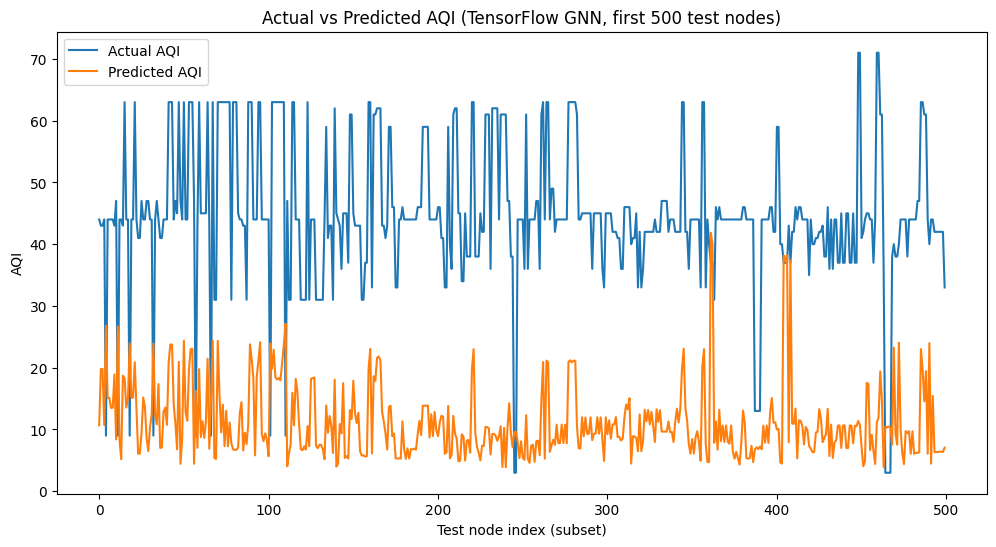

In [7]:
preds_all = gnn_model(X_tf, training=False).numpy().reshape(-1)
y_all = y_np

test_idx = np.where(test_mask)[0]
y_true_test = y_all[test_idx]
y_pred_test = preds_all[test_idx]

mse  = mean_squared_error(y_true_test, y_pred_test)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true_test, y_pred_test)
mape = np.mean(np.abs((y_true_test - y_pred_test) / np.maximum(y_true_test, 1e-6))) * 100
r2   = r2_score(y_true_test, y_pred_test)

print(f"\nGNN Test Metrics:")
print(f"MSE: {mse:.3f} | RMSE: {rmse:.3f} | MAE: {mae:.3f} | MAPE: {mape:.2f}% | R²: {r2:.3f}")

# %%
plt.figure(figsize=(12,6))
plt.plot(y_true_test[:500], label="Actual AQI")
plt.plot(y_pred_test[:500], label="Predicted AQI")
plt.title("Actual vs Predicted AQI (TensorFlow GNN, first 500 test nodes)")
plt.xlabel("Test node index (subset)")
plt.ylabel("AQI")
plt.legend()
plt.show()



Permutation Feature Importance (GNN, R² drop):
        Feature  Importance
0    AQI_roll_3    0.106943
1     AQI_lag_1    0.081878
2     AQI_lag_7    0.076464
3    AQI_roll_7    0.075344
4            O3    0.072242
5     AQI_lag_3    0.069102
6           NO2    0.062923
7     PM25xTemp    0.060504
8    NO2_roll_3    0.056630
9    NO2_roll_7    0.049936
10         PM25    0.045066
11  PM25_roll_3    0.042076
12  PM25_roll_7    0.038815
13    O3_roll_3    0.038707
14   is_weekend    0.034730


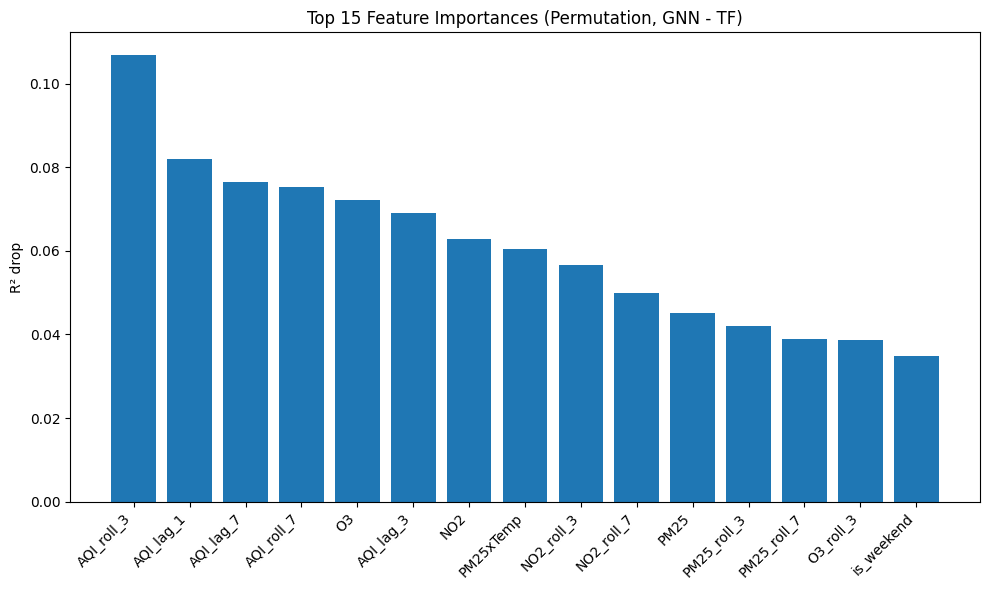

In [8]:
def permutation_importance_gnn_tf(
    model, X_base, y_all, test_mask_bool, feature_names, n_repeats=3, metric=r2_score
):
    """
    X_base: (N, F) numpy (scaled)
    y_all:  (N,) numpy
    test_mask_bool: (N,) bool numpy
    """
    X_base_tf = tf.constant(X_base, dtype=tf.float32)
    preds_all = model(X_base_tf, training=False).numpy().reshape(-1)
    base_r2 = metric(y_all[test_mask_bool], preds_all[test_mask_bool])

    importances = {}
    for j, feat in enumerate(feature_names):
        scores = []
        for _ in range(n_repeats):
            X_perm = X_base.copy()
            # Permute this feature across all nodes
            perm = np.random.permutation(X_perm.shape[0])
            X_perm[:, j] = X_perm[perm, j]

            X_perm_tf = tf.constant(X_perm, dtype=tf.float32)
            preds_perm = model(X_perm_tf, training=False).numpy().reshape(-1)
            r2_perm = metric(y_all[test_mask_bool], preds_perm[test_mask_bool])
            scores.append(base_r2 - r2_perm)

        importances[feat] = float(np.mean(scores))

    return importances

feat_importances = permutation_importance_gnn_tf(
    gnn_model, X_scaled, y_all, test_mask, FEATURES, n_repeats=3
)

imp_df = pd.DataFrame(
    sorted(feat_importances.items(), key=lambda x: x[1], reverse=True),
    columns=["Feature", "Importance"]
)

print("\nPermutation Feature Importance (GNN, R² drop):")
print(imp_df.head(15))

plt.figure(figsize=(10,6))
plt.bar(imp_df["Feature"][:15], imp_df["Importance"][:15])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R² drop")
plt.title("Top 15 Feature Importances (Permutation, GNN - TF)")
plt.tight_layout()
plt.show()



In [9]:
# Pick first test node
test_indices = np.where(test_mask)[0]
node_index = int(test_indices[0])

X_tab = X_scaled  # (N, F)
X_train_tab = X_tab[train_idx]
X_test_tab  = X_tab[test_indices]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_tab,
    feature_names=FEATURES,
    mode='regression'
)

def predict_gnn_for_lime(z_batch: np.ndarray) -> np.ndarray:
    """
    z_batch: (n_samples, F) - perturbed versions of ONE node.
    For each row, replace that node's feature vector in the full graph,
    run the GNN, and return only that node's prediction.
    """
    preds = []
    for z in z_batch:
        X_mod = X_tab.copy()
        X_mod[node_index] = z
        X_mod_tf = tf.constant(X_mod, dtype=tf.float32)
        out = gnn_model(X_mod_tf, training=False).numpy().reshape(-1)
        preds.append(out[node_index])
    return np.array(preds)

sample = X_test_tab[0]

exp = lime_explainer.explain_instance(
    data_row=sample,
    predict_fn=predict_gnn_for_lime,
    num_features=10
)

try:
    display(HTML(exp.as_html()))
except Exception:
    print("LIME Explanation:")
    for feature, weight in exp.as_list():
        print(f"{feature}: {weight:.4f}")

with open("exp18_gnn_lime_explanation.html", "w") as f:
    f.write(exp.as_html())


100%|██████████| 50/50 [35:24:34<00:00, 2549.49s/it]   


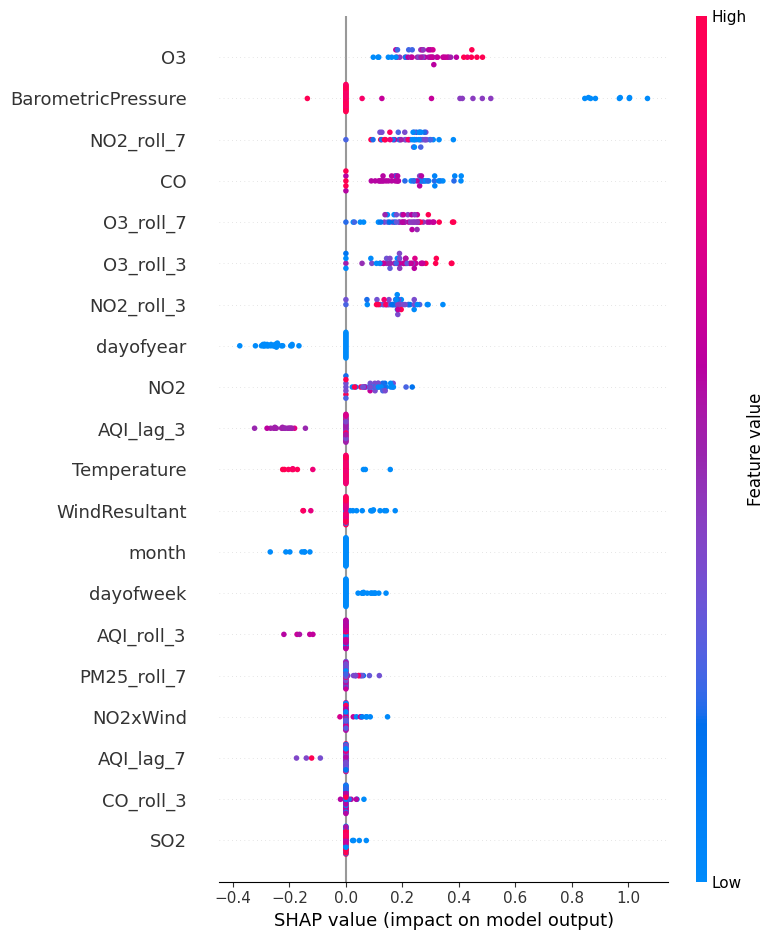

In [10]:
# Background sample for SHAP
background_size = min(100, X_train_tab.shape[0])
background = X_train_tab[:background_size]

def shap_predict(z_batch: np.ndarray) -> np.ndarray:
    """
    Same as predict_gnn_for_lime, but works on batches.
    """
    preds = []
    for z in z_batch:
        X_mod = X_tab.copy()
        X_mod[node_index] = z
        X_mod_tf = tf.constant(X_mod, dtype=tf.float32)
        out = gnn_model(X_mod_tf, training=False).numpy().reshape(-1)
        preds.append(out[node_index])
    return np.array(preds)

shap_explainer = shap.KernelExplainer(shap_predict, background)

# Small subset from test for SHAP
test_sample_size = min(50, X_test_tab.shape[0])
test_samples = X_test_tab[:test_sample_size]

shap_values = shap_explainer.shap_values(test_samples, nsamples=200)

shap.summary_plot(shap_values, test_samples, feature_names=FEATURES)

